In [9]:
import pandas as pd
import numpy as np

gal = pd.read_csv("galaxy_catalogue_300Mpc.csv")
N_gal = len(gal)


Raw per-galaxy kilonova rates:
count    1.000000e+04
mean     1.247625e-10
std      7.742062e-09
min      1.170623e-19
25%      2.652221e-18
50%      1.076294e-17
75%      1.047589e-16
max      6.087614e-07
Name: kn_rate, dtype: float64

Raw total kilonova rate in volume: 1.248e-06 yr^-1

Renormalised total kilonova rate: 30.00 yr^-1


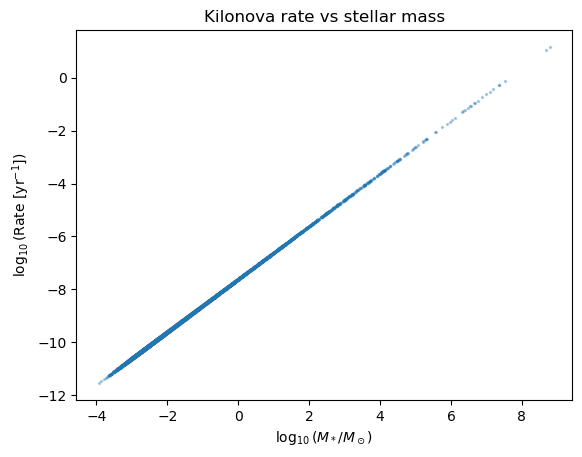

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --------------------------------------------------
# Load frozen galaxy catalogue
# --------------------------------------------------
gal = pd.read_csv("galaxy_catalogue_300Mpc.csv")
N_gal = len(gal)

# --------------------------------------------------
# Define mass-weighted kilonova rate model
# --------------------------------------------------
# Assumption:
# BNS merger rate traces stellar mass only

# Convert log stellar mass to linear mass
M_star = 10**gal["logM_star"]  # Msun

# Initial reference rate (will be renormalised)
R0 = 1e-5  # yr^-1 per 1e10 Msun

# Per-galaxy raw rate
gal["kn_rate"] = R0 * (M_star / 1e10)

# --------------------------------------------------
# Validate raw rates
# --------------------------------------------------
print("Raw per-galaxy kilonova rates:")
print(gal["kn_rate"].describe())

raw_total_rate = gal["kn_rate"].sum()
print(f"\nRaw total kilonova rate in volume: {raw_total_rate:.3e} yr^-1")

# --------------------------------------------------
# Renormalise to match observed local volumetric rate
# --------------------------------------------------
# Target: ~10–100 events per year in 300 Mpc
target_total_rate = 30.0  # yr^-1 (mid-range choice)

scale_factor = target_total_rate / raw_total_rate
gal["kn_rate"] *= scale_factor

# --------------------------------------------------
# Final validation
# --------------------------------------------------
final_total_rate = gal["kn_rate"].sum()
print(f"\nRenormalised total kilonova rate: {final_total_rate:.2f} yr^-1")

# --------------------------------------------------
# Diagnostic plot: rate vs stellar mass
# --------------------------------------------------
plt.figure()
plt.scatter(
    gal["logM_star"],
    np.log10(gal["kn_rate"]),
    s=2,
    alpha=0.3
)
plt.xlabel(r"$\log_{10}(M_*/M_\odot)$")
plt.ylabel(r"$\log_{10}(\mathrm{Rate\ [yr^{-1}]})$")
plt.title("Kilonova rate vs stellar mass")
plt.show()


In [18]:
T_obs = 10.0  # years


In [19]:
# Observation time
T_obs = 10.0  # years

# Expected number of events per galaxy
expected_events = gal["kn_rate"] * T_obs

# Poisson draw
gal["N_events"] = np.random.poisson(expected_events)


In [20]:
print("Galaxies with at least one event:", (gal["N_events"] > 0).sum())
print("Total number of events:", gal["N_events"].sum())


Galaxies with at least one event: 12
Total number of events: 292


In [21]:
# --------------------------------------------------
# Build kilonova event table
# --------------------------------------------------

event_rows = []
event_id = 0

for _, row in gal.iterrows():
    n = int(row["N_events"])
    if n > 0:
        times = np.random.uniform(0.0, T_obs, size=n)
        for t in times:
            event_rows.append({
                "event_id": event_id,
                "gal_id": int(row["gal_id"]),
                "event_time": t,              # years
                "distance": row["distance"],  # Mpc
                "logM_star": row["logM_star"],
                "is_quiescent": bool(row["is_quiescent"])
            })
            event_id += 1

events = pd.DataFrame(event_rows)


In [22]:
print(f"Total number of events: {len(events)}")
events.head()


Total number of events: 292


,event_id,gal_id,event_time,distance,logM_star,is_quiescent
0,0,307,6.480016,205.827115,6.993339,True
1,1,1275,9.841443,141.499441,8.677181,True
2,2,1275,7.701726,141.499441,8.677181,True
3,3,1275,8.064430,141.499441,8.677181,True
4,4,1275,2.873017,141.499441,8.677181,True


In [23]:
events["event_time"].describe()


count    292.000000
mean       4.983282
std        2.805229
min        0.062714
25%        2.551466
50%        5.067955
75%        7.431146
max        9.959743
Name: event_time, dtype: float64

In [24]:
events.to_csv("kilonova_events_300Mpc_10yr.csv", index=False)
print("Event table saved.")


Event table saved.


In [25]:
import numpy as np
import pandas as pd

events = pd.read_csv("kilonova_events_300Mpc_10yr.csv")
N_events = len(events)

print(f"Number of events: {N_events}")


Number of events: 292


In [26]:
# Peak absolute magnitude distribution
M_peak_mean = -16.0
M_peak_sigma = 0.7

events["M_peak"] = np.random.normal(
    loc=M_peak_mean,
    scale=M_peak_sigma,
    size=N_events
)


In [27]:
events["M_peak"].describe()


count    292.000000
mean     -16.025699
std        0.649452
min      -18.197192
25%      -16.433413
50%      -16.021647
75%      -15.626279
max      -13.757647
Name: M_peak, dtype: float64

In [28]:
tau = 1.5  # days

def kilonova_mag(M_peak, delta_t_days):
    """
    Simple exponential-decline kilonova light curve.
    """
    return M_peak + (delta_t_days / tau)


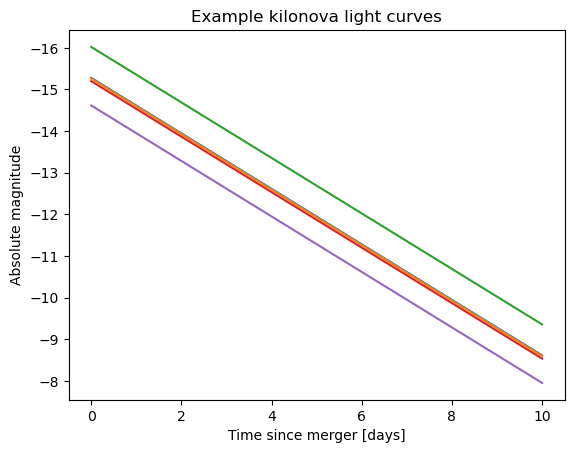

In [29]:
import matplotlib.pyplot as plt

t_days = np.linspace(0, 10, 200)

plt.figure()
for i in np.random.choice(N_events, size=5, replace=False):
    mags = kilonova_mag(events.loc[i, "M_peak"], t_days)
    plt.plot(t_days, mags)

plt.gca().invert_yaxis()
plt.xlabel("Time since merger [days]")
plt.ylabel("Absolute magnitude")
plt.title("Example kilonova light curves")
plt.show()
